# Import Packages

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# DataLoader

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# VAE

In [3]:
class BetaVAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(BetaVAE, self).__init__()
        self.latent_dim = latent_dim

        # ===========Encoder==========
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(128*4*4, latent_dim)
        self.fc_logvar = nn.Linear(128*4*4, latent_dim)

        # ===========Decoder==========
        self.fc_decode = nn.Linear(latent_dim, 128*4*4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h_flat = self.flatten(h)
        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 128, 4, 4)
        x_hat = self.decoder(h)
        return x_hat[:, :, :28, :28]

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

# Beta VAE loss

In [4]:
def beta_vae_loss(x, x_hat, mu, logvar, beta=4.0):
    # Reconstruction loss: binary cross entropy
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction='sum')

    # KL divergence between q(z|x) and N(0,I)
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta * kl_div, recon_loss, kl_div

# Train

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BetaVAE(latent_dim=20).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 50
beta = 4.0
losses, recons, kls = [], [], []

for epoch in range(num_epochs):
    print("="*20, f"Epoch = {epoch}", "="*20)
    model.train()
    total_loss, total_recon, total_kl = 0, 0, 0

    for batch in tqdm(train_loader):
        x, _ = batch
        x = x.to(device)

        x_hat, mu, logvar = model(x)
        loss, recon, kl = beta_vae_loss(x, x_hat, mu, logvar, beta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

    losses.append(total_loss / len(train_loader.dataset))
    recons.append(total_recon / len(train_loader.dataset))
    kls.append(total_kl / len(train_loader.dataset))

    print(f"Epoch {epoch+1}, Loss: {losses[-1]:.2f}, Recon: {recons[-1]:.2f}, KL: {kls[-1]:.2f}")


====================Epoch = 0 ====================


100%|██████████| 469/469 [00:13<00:00, 34.58it/s]


Epoch 1, Loss: 195.51, Recon: 177.26, KL: 4.56
====================Epoch = 1 ====================


100%|██████████| 469/469 [00:13<00:00, 35.76it/s]


Epoch 2, Loss: 154.94, Recon: 120.76, KL: 8.55
====================Epoch = 2 ====================


...

Epoch 48, Loss: 140.82, Recon: 100.34, KL: 10.12
====================Epoch = 48 ====================


100%|██████████| 469/469 [00:12<00:00, 38.81it/s]


Epoch 49, Loss: 140.68, Recon: 100.23, KL: 10.11
====================Epoch = 49 ====================


100%|██████████| 469/469 [00:12<00:00, 37.52it/s]

Epoch 50, Loss: 140.70, Recon: 100.19, KL: 10.13


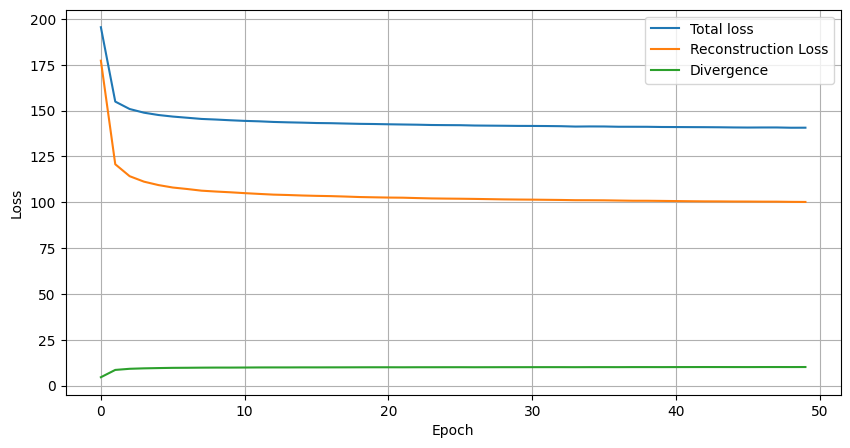

In [6]:
plt.figure(figsize=(10,5))
plt.plot(losses, label="Total loss")
plt.plot(recons, label="Reconstruction Loss")
plt.plot(kls, label="Divergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Generate Sample

In [7]:
def generate_images(model, num_images=16):
    model.eval()
    with torch.no_grad():
        z = torch.randn(num_images, model.latent_dim).to(device)
        samples = model.decode(z)
    return samples.cpu()

In [8]:
samples = generate_images(model)

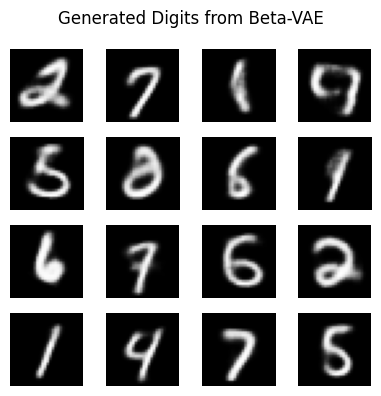

In [9]:
plt.figure(figsize=(4, 4))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(samples[i][0], cmap='gray')
    plt.axis('off')
plt.suptitle("Generated Digits from Beta-VAE")
plt.tight_layout()
plt.show()